# W02 SDS Part 1 ESDA

This notebook uses python and pysal to do the following:

- Read in a geojson file
- Map/calculate basic stats of a field
- Calculate Moran's I to quantify the degree of spatial autocorrelation
- Moran Scatterplot
- LISA


PySAL: python spatial analysis library (https://pysal.org)

If you have `pysal` installed, you may not need to install these, othwise remove the hashtag and run it.

In [1]:
#pip install -q libpysal

In [2]:
#pip install -q splot

### Importing necessary libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


#from pysal
from libpysal.weights.contiguity import Queen
from splot.esda import moran_scatterplot,plot_moran,lisa_cluster
from esda.moran import Moran, Moran_Local
import splot

### Load example florida county-level data

In [4]:
path = "https://raw.githubusercontent.com/Ziqi-Li/GIS5106/refs/heads/main/data/fl_counties.geojson"

fl_county_df = gpd.read_file(path)

### Make a quick map

Text(0.5, 1.0, 'Median Monthly Housing Costs ($)')

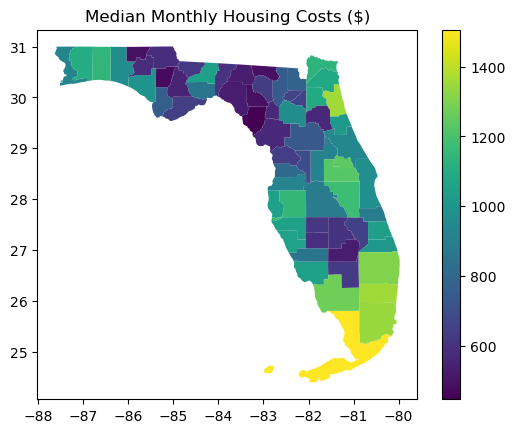

In [5]:
fl_county_df.plot(fl_county_df['monthly_housing_costs'].values,legend=True)


plt.title('Median Monthly Housing Costs ($)')

### Plot the distribution

Text(0, 0.5, '# of counties')

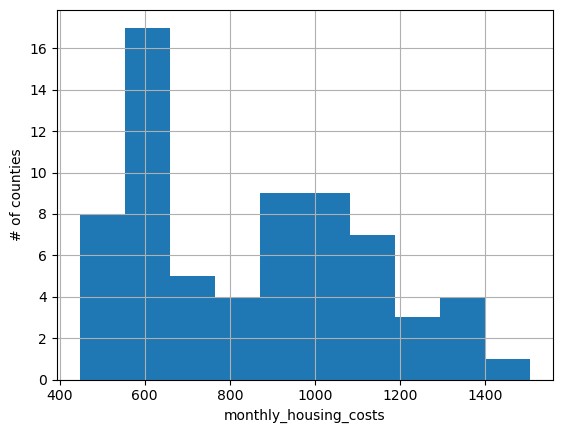

In [6]:
fl_county_df['monthly_housing_costs'].hist()

plt.xlabel("monthly_housing_costs")
plt.ylabel("# of counties")

### Calculate descriptive statistics

In [7]:
fl_county_df['monthly_housing_costs'].describe()

count      67.000000
mean      856.119403
std       272.332379
min       447.000000
25%       608.500000
50%       856.000000
75%      1051.000000
max      1506.000000
Name: monthly_housing_costs, dtype: float64

## Global Moran's I and p-value

### Specify a weight matrix

In [8]:
w = Queen.from_dataframe(fl_county_df) #Generate W matrix using Queen contiguity


#w = Rook.from_dataframe(fl_county_df) #Alternatively generate W matrix using Rook contiguity


w.transform = 'r' #Row-standardization of the weight matrix, to ensure index between -1 to 1

/var/folders/mp/9px298sd6vs8xccb_3sql0dr0000gp/T/ipykernel_62709/211280662.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(fl_county_df) #Generate W matrix using Queen contiguity


### Calculate Moran's I

In [9]:
from esda.moran import Moran

housing_costs = fl_county_df['monthly_housing_costs'].values #Get the variable we are interested.

global_moran = Moran(housing_costs, w, permutations=999) #Permutation test for 999 times to get p-value

global_moran.I

0.4771382216983452

The Moran's I value tells us there is moderate level of positive spatial autocorrelation.

p-value

In [10]:
global_moran.p_sim # P value based on the permutation test

0.001

This is indicating that the observed positive spatial autocorrelation of the median housing costs map is statistically significant (p<0.05).

In other words, if we assume the pattern to be random, there is around ~0.1% probability that we will observe more patterning than in our real data. so the spatial pattern is very unlikely to be random.  

## Moran Scatterplot

/Users/ziqili/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0, 'monthly_housing_costs')

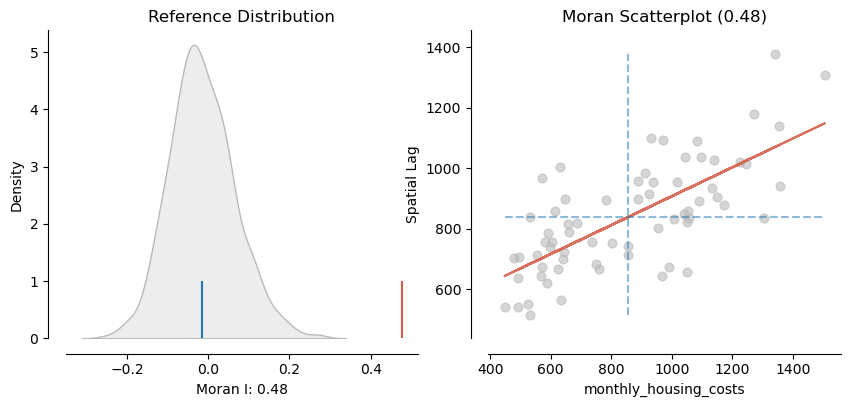

In [11]:
from splot.esda import plot_moran

plot_moran(global_moran,
           zstandard=False, #True the data will be normalized (mean removed and divided by std)
           figsize=(10,4)
          )

plt.xlabel("monthly_housing_costs")

The left is the null sampling distribution of Moran's I under assumption of spatial randomness, obtained from the permutation test above. The blue bar is the position of the expected Moran's I value (-1/(n-1)), and the red bar marks the observed Moran's I value (0.48).

The chart on the right is a Moran Scatterplot, in which the x-axis is the value, the y-axis is the average value in the close neighborhood (the spatial lag).

## Local Moran's I (LISA)

Generate a better Moran Scatterplot with significance of the local moran's Is.

Color code each county with the quadrant it falls into.
- Red: HH (High values near high values)
- Light Blue: LH
- Yellow: HL
- Blue: LL

Text(0, 0.5, 'Averaged Housing Costs in the Close Neighborhoods')

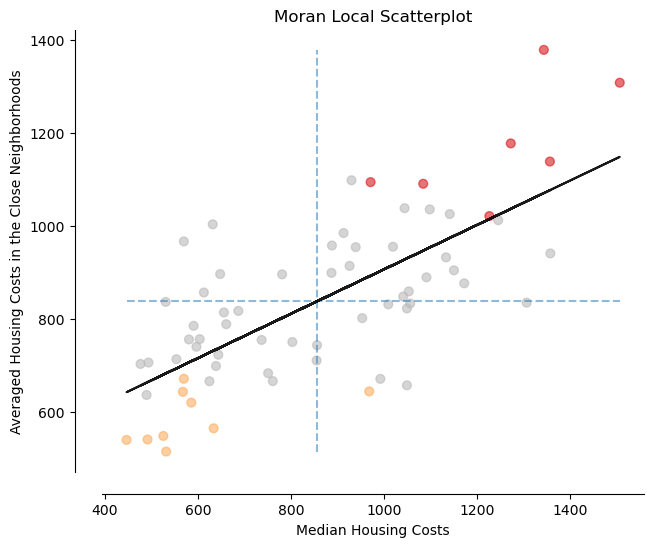

In [12]:
from splot.esda import moran_scatterplot
from esda.moran import Moran_Local

# calculate Moran_Local and plot
moran_local = Moran_Local(housing_costs, w, permutations=999)


fig, ax = moran_scatterplot(moran_local, zstandard=False, p=0.05)

#Labelling
ax.set_xlabel('Median Housing Costs')
ax.set_ylabel('Averaged Housing Costs in the Close Neighborhoods')


Create a hot-spot and cold-spot map.
- HH: High % Bach county surrounded by High % Bach county
- LL: Low-Low
- LH: Low-High
- HL: High-Low
- NS: Non-significant (p>0.05)

(<Figure size 600x600 with 1 Axes>, <Axes: >)

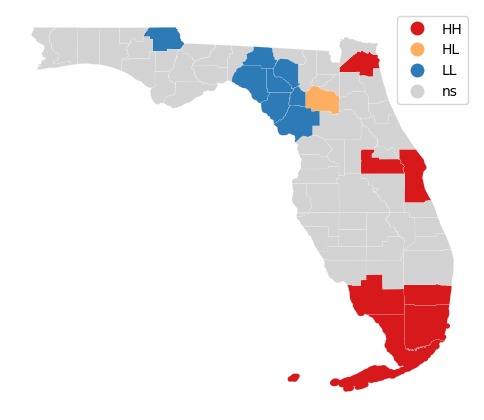

In [13]:
from splot.esda import lisa_cluster

lisa_cluster(moran_loc=moran_local,
             gdf=fl_county_df,
             p = 0.05, # the level of p-value threshold to mask for non-significance
             figsize = (6,6))

The red counties represent areas with high housing costs, and their neighboring counties also exhibit high housing costs. We can see that the southeastern part of Florida, as well as Brevard and Duval counties, are within this high–high (HH) cluster. There are also several counties shown in blue, which represent cold spots. Alachua County appears to be an outlier, where housing costs are high but the surrounding counties have relatively low housing costs.